<a href="https://colab.research.google.com/github/OgunbanjoT/Ethical-AI-Analysis/blob/main/AI_Assignment15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PROJECT: Iris Flower Species Classification
# GOAL: Predict the specific species of an iris flower based on its physical measurements.
# IMPORTANCE: This is a classic classification problem in AI. In the real world,
# automated taxonomic identification helps botanists, agricultural tech companies,
# and ecological researchers track biodiversity and plant health automatically.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset directly from scikit-learn
iris = load_iris()

# Convert to a DataFrame for easier exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map numerical targets to actual species names for better readability
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_map)

print("Dataset successfully loaded!")
print(f"Dataset shape: {df.shape} (150 rows, 6 columns)")
df.head()

Dataset successfully loaded!
Dataset shape: (150, 6) (150 rows, 6 columns)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [2]:
# Check for missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())

--- Missing Values Check ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [3]:
# Basic statistics of the dataset
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  



Generating Pairplot...


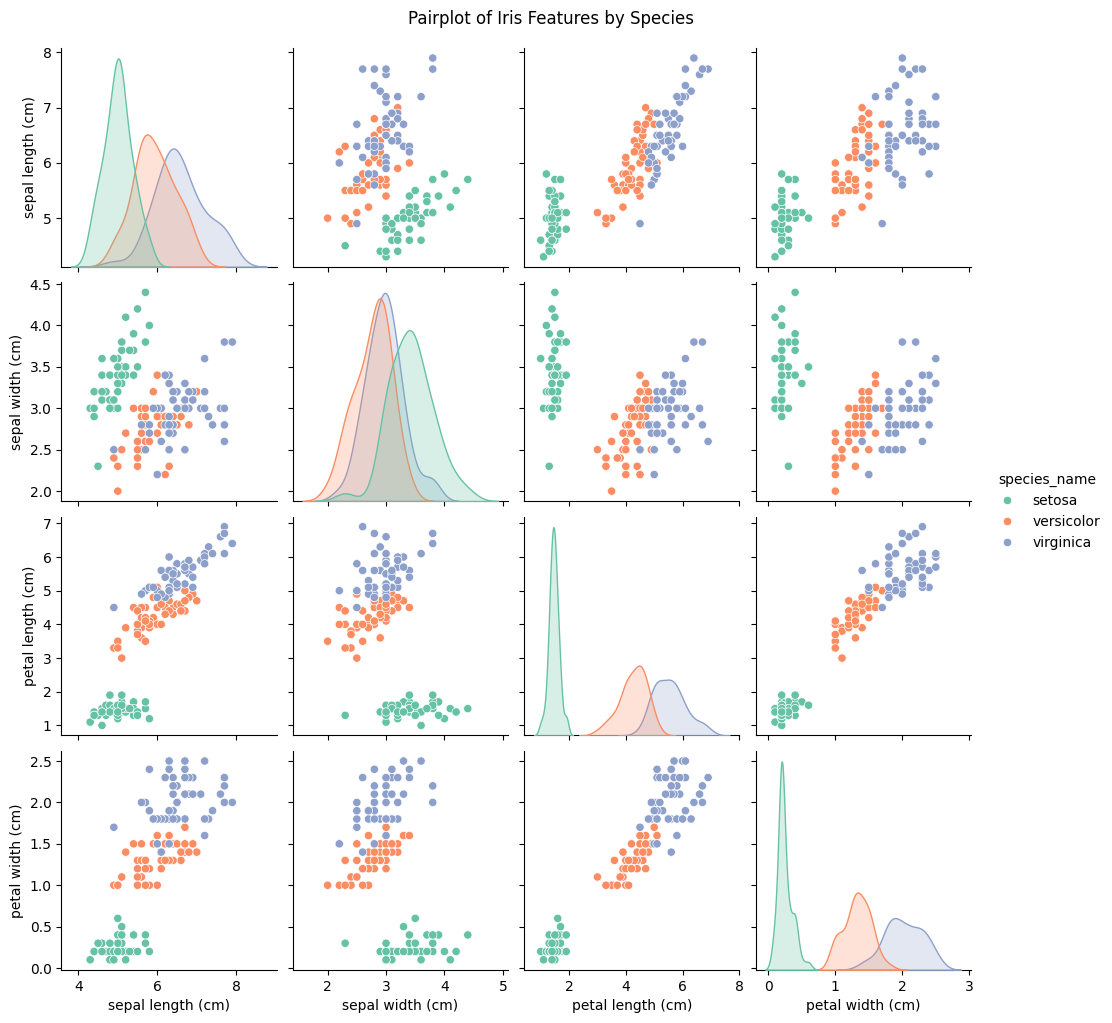

In [4]:
# Data Visualization 1: Pairplot to see feature relationships
print("\nGenerating Pairplot...")
sns.pairplot(df.drop('species', axis=1), hue='species_name', palette='Set2')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()


Generating Correlation Heatmap...


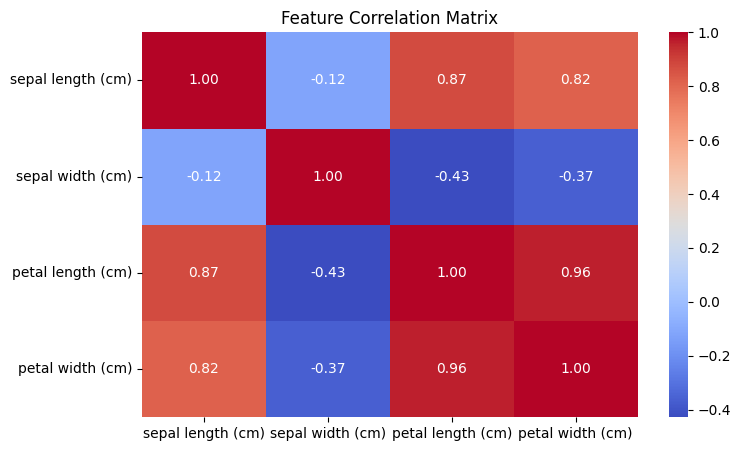

In [5]:
# Data Visualization 2: Correlation Heatmap
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(8, 5))
sns.heatmap(df.drop(['species_name', 'species'], axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [6]:
# Splitting the features (X) and target (y)
X = df[iris.feature_names]
y = df['species']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features (Data Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nData split completed: Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


Data split completed: Training samples: 120, Testing samples: 30


In [7]:
# We select a Random Forest Classifier because it handles multi-class classification
# beautifully and is highly robust against overfitting.

# Initialize the baseline model
rf_baseline = RandomForestClassifier(random_state=42)

# Define Hyperparameter grid for Tuning (GridSearchCV)
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 3, 5],
    'min_samples_split': [2, 5]
}

# Use Cross-Validation (5-Fold CV) to find the best parameters
grid_search = GridSearchCV(estimator=rf_baseline, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Extract the best optimized model
best_model = grid_search.best_estimator_

print("--- Model Optimization Complete ---")
print(f"Best Hyperparameters found: {grid_search.best_params_}")

--- Model Optimization Complete ---
Best Hyperparameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}


In [8]:
# Predict using the optimized model on the test data
y_pred = best_model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy * 100:.2f}%\n")

Model Accuracy on Test Set: 96.67%



In [9]:
# Detailed Classification Report (Precision, Recall, F1-Score)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



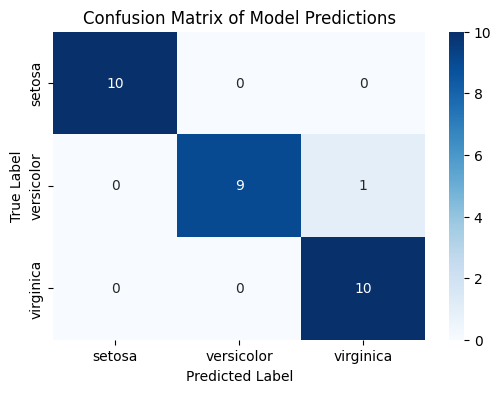

In [10]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix of Model Predictions')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [11]:
# Create an interactive widget directly inside Google Colab so users can test inputs.
import ipywidgets as widgets
from IPython.display import display

print("📊 INTERACTIVE MODEL DEPLOYMENT INTERFACE")
print("Adjust the sliders below to predict the flower species in real-time:")

📊 INTERACTIVE MODEL DEPLOYMENT INTERFACE
Adjust the sliders below to predict the flower species in real-time:


In [12]:
# Setup the sliders based on the min/max values of the actual dataset
sepal_length_slider = widgets.FloatSlider(value=5.8, min=4.3, max=7.9, step=0.1, description='Sepal Length:')
sepal_width_slider = widgets.FloatSlider(value=3.0, min=2.0, max=4.4, step=0.1, description='Sepal Width:')
petal_length_slider = widgets.FloatSlider(value=3.8, min=1.0, max=6.9, step=0.1, description='Petal Length:')
petal_width_slider = widgets.FloatSlider(value=1.2, min=0.1, max=2.5, step=0.1, description='Petal Width:')

# Output area for results
output = widgets.Output()

def make_prediction(change):
    with output:
        output.clear_output()
        # Collect raw inputs from the sliders
        raw_inputs = np.array([[sepal_length_slider.value,
                                sepal_width_slider.value,
                                petal_length_slider.value,
                                petal_width_slider.value]])

        # Crucial Step: Scale the inputs just like the training data
        scaled_inputs = scaler.transform(raw_inputs)

        # Predict
        prediction_id = best_model.predict(scaled_inputs)[0]
        predicted_species = iris.target_names[prediction_id]
        probabilities = best_model.predict_proba(scaled_inputs)[0]
        confidence = probabilities[prediction_id] * 100

        # Display nicely
        print(f"🔮 Predicted Species: **{predicted_species.upper()}**")
        print(f"🎲 Model Confidence: {confidence:.2f}%")

# Attach the prediction function to slider updates
sepal_length_slider.observe(make_prediction, names='value')
sepal_width_slider.observe(make_prediction, names='value')
petal_length_slider.observe(make_prediction, names='value')
petal_width_slider.observe(make_prediction, names='value')

# Display UI Components
ui = widgets.VBox([sepal_length_slider, sepal_width_slider, petal_length_slider, petal_width_slider])
display(ui, output)

# Run once initially to show a starting prediction
make_prediction(None)

Output()